In [1]:
print('hello')

hello


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose 
from statsmodels.tsa.holtwinters import SimpleExpSmoothing,ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from scipy.stats import boxcox
%matplotlib inline


In [53]:
df=pd.read_csv('AirPassengers.csv')

In [54]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [56]:
df['Month']=df['Month'].apply(lambda x:x+'-01')

In [57]:
df['Month']=pd.to_datetime(df['Month'])

In [58]:
df.set_index(keys='Month',inplace=True)

<Axes: xlabel='Month'>

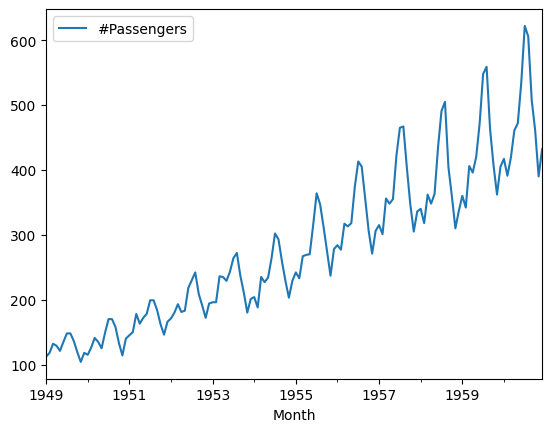

In [7]:
df.plot()

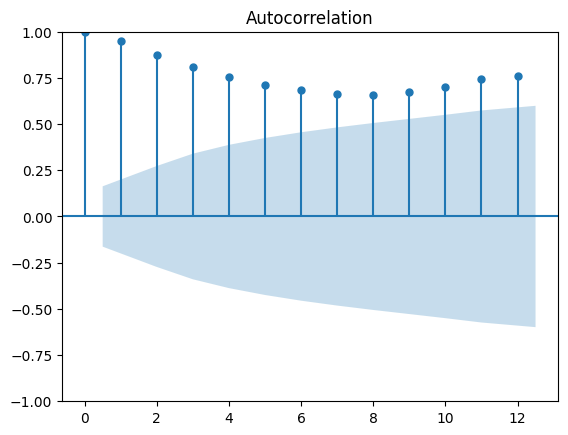

In [8]:
acf=plot_acf(df,lags=12)

In [9]:
y_transformed, fitted_lambda = boxcox(df['#Passengers'])
print(y_transformed,fitted_lambda)
# To reverse (inverse transform)
#from scipy.special import inv_boxcox
#y_original = inv_boxcox(y_transformed, fitted_lambda)

[ 6.82748944  6.93282161  7.16189084  7.11461012  6.98378623  7.20826475
  7.39959724  7.39959724  7.22352766  6.94993125  6.67930053  6.93282161
  6.88074086  7.06638315  7.29843778  7.20826475  7.05009001  7.41371414
  7.69297679  7.69297679  7.53725932  7.17744769  6.86312327  7.28363886
  7.35675338  7.42775055  7.79166223  7.60332606  7.71801318  7.79166223
  8.03379875  8.03379875  7.86322572  7.59025219  7.3711179   7.64214177
  7.70552617  7.81574207  7.96692931  7.82769663  7.85143788  8.23478438
  8.35415709  8.46833648  8.14152362  7.94424571  7.71801318  7.97819611
  8.00058204  8.00058204  8.41186515  8.4023346   8.34441466  8.47763214
  8.66568525  8.73398191  8.42136135  8.16253982  7.81574207  8.05570698
  8.08822362  7.90983791  8.4023346   8.32482058  8.39276944  8.66568525
  8.97573598  8.90544272  8.62209902  8.34441466  8.07743027  8.34441466
  8.46833648  8.38316938  8.69150052  8.70857375  8.71706984  9.07418354
  9.41661519  9.30252283  9.05177643  8.75078836  8

In [10]:
df['#Passengers_box_cox']=y_transformed

In [11]:
df.head()

,#Passengers,#Passengers_box_cox
Month,,
1949-01-01,112,6.827489
1949-02-01,118,6.932822
1949-03-01,132,7.161891
1949-04-01,129,7.114610
1949-05-01,121,6.983786


<Axes: xlabel='Month'>

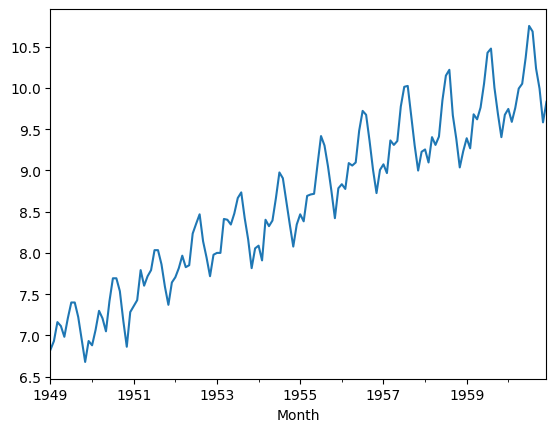

In [12]:
df['#Passengers_box_cox'].plot()

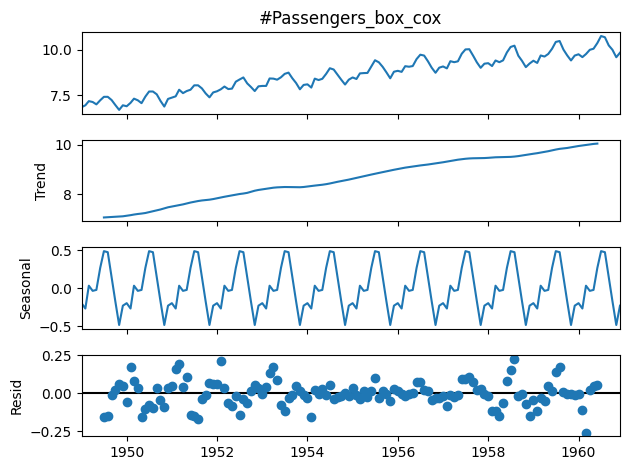

In [13]:
decompose_result=seasonal_decompose(df['#Passengers_box_cox'],model='additive',period=12)
residuals=decompose_result.resid.dropna()
decompose_result.plot()
plt.show()

In [14]:
residuals=decompose_result.resid.dropna()

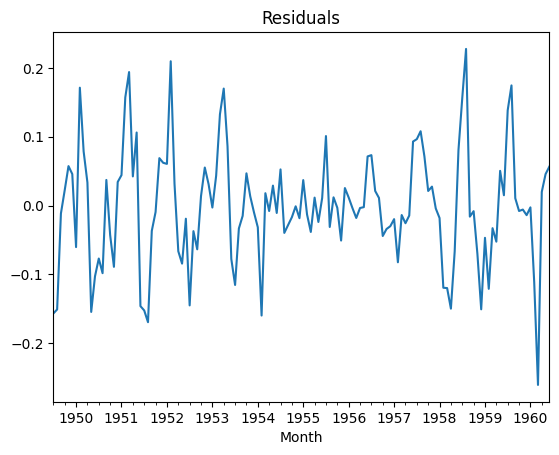

In [15]:
residuals.plot(title='Residuals')
plt.show()

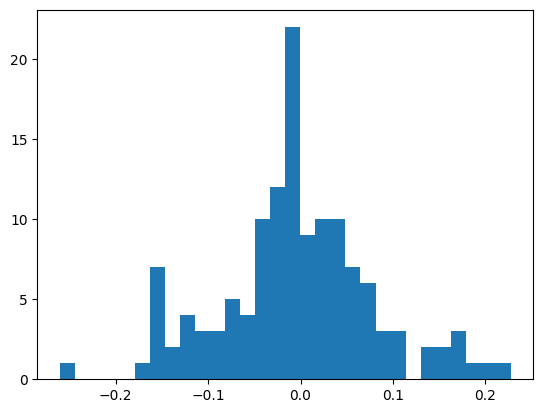

In [16]:
plt.hist(residuals,bins=30)
plt.show()

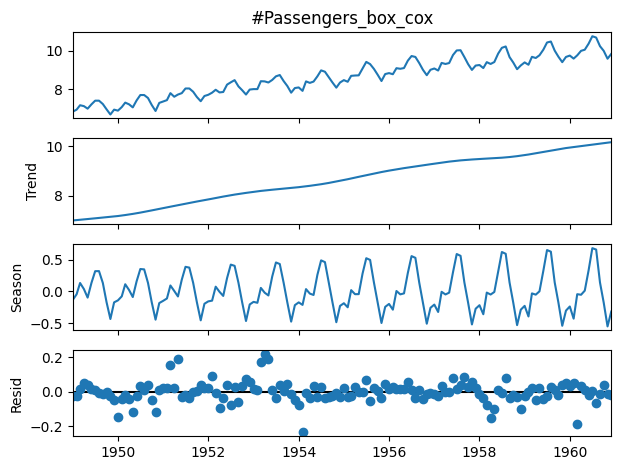

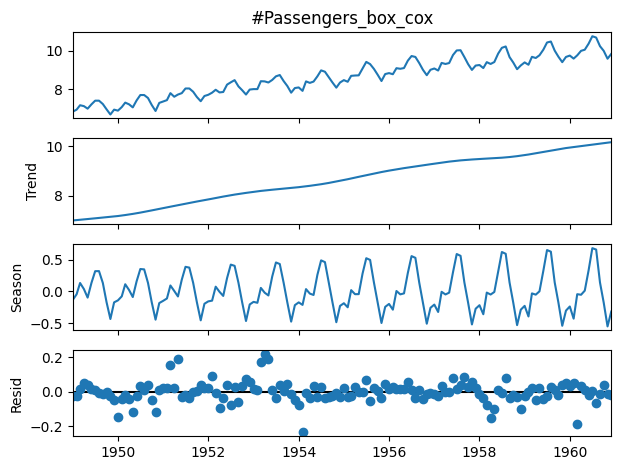

In [17]:
from statsmodels.tsa.seasonal import STL
stl = STL(df['#Passengers_box_cox'], seasonal=13, trend=25, robust=True)
result = stl.fit()
result.plot()

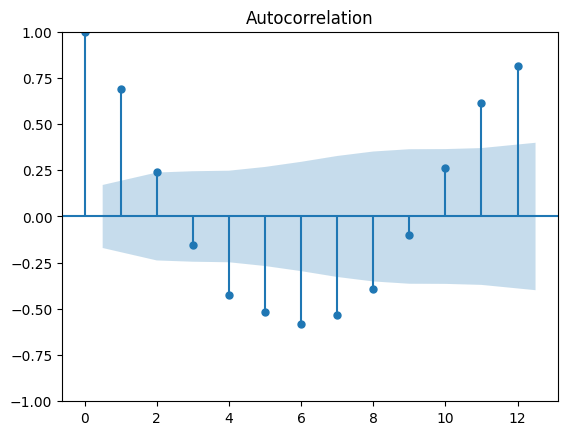

In [18]:
decompose_result=seasonal_decompose(df['#Passengers'],model='additive',period=13)
residuals=decompose_result.resid.dropna()
acf=plot_acf(residuals.dropna(),lags=12)

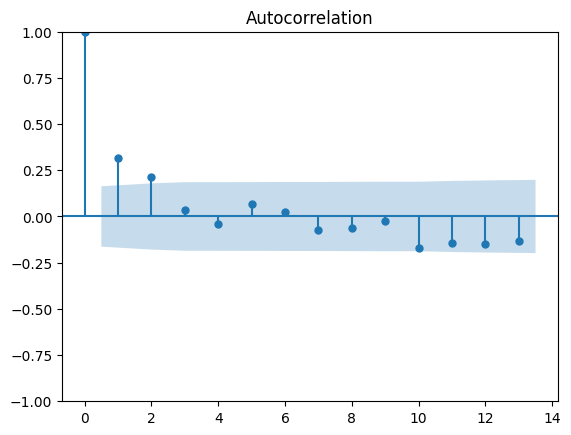

In [19]:
from statsmodels.tsa.seasonal import STL
stl = STL(df['#Passengers_box_cox'], seasonal=13, trend=25, robust=True)
result = stl.fit()
residuals=result.resid
acf=plot_acf(residuals.dropna(),lags=13)

<Axes: xlabel='Month'>

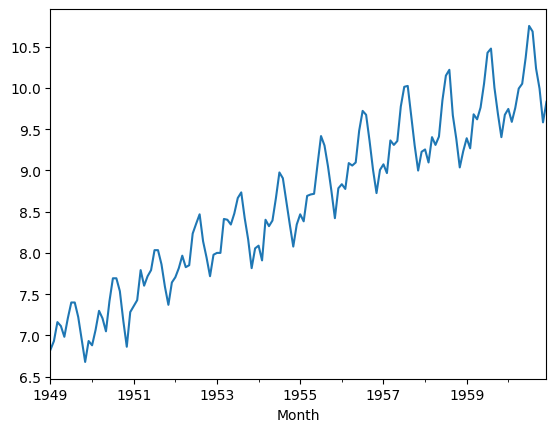

In [20]:
df['#Passengers_box_cox'].plot()

In [21]:
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(residuals, lags=[13], return_df=True)

,lb_stat,lb_pvalue
13,38.36734,0.000252


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   #Passengers          144 non-null    int64  
 1   #Passengers_box_cox  144 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 3.4 KB


In [22]:
df['#Passengers_box_cox'].tail()

Month
1960-08-01    10.684048
1960-09-01    10.234572
1960-10-01     9.992158
1960-11-01     9.582622
1960-12-01     9.831859
Name: #Passengers_box_cox, dtype: float64

In [60]:
df['#Passengers_box_cox'].head()

Month
1949-01-01    6.827489
1949-02-01    6.932822
1949-03-01    7.161891
1949-04-01    7.114610
1949-05-01    6.983786
Name: #Passengers_box_cox, dtype: float64

In [23]:
train,test=df['#Passengers_box_cox'][:'1958-12-01'],df['#Passengers_box_cox']['1959-01-01':]

C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


fitted_model = ExponentialSmoothing(train1,trend='add',seasonal='add',seasonal_periods=365,initialization_method='estimated',missing='drop').fit()

test_predictions = fitted_model.forecast(364)
forecast_index = pd.date_range(start=test.index[0], periods=364, freq='D') 
test_predictions = pd.Series(test_predictions.values,index=forecast_index)


train1.plot(legend=True,label='TRAIN')
test['log_sales'].plot(legend=True,label='TEST',figsize=(6,4))
test_predictions.plot(legend=True,label='PREDICTION')
plt.title('Train, Test and Predicted data points using Holt Winters Exponential Smoothing')
plt.show()

In [68]:
train

Month
1949-01-01     6.827489
1949-02-01     6.932822
1949-03-01     7.161891
1949-04-01     7.114610
1949-05-01     6.983786
                ...    
1958-08-01    10.219682
1958-09-01     9.668139
1958-10-01     9.383538
1958-11-01     9.036736
1958-12-01     9.233166
Name: #Passengers_box_cox, Length: 120, dtype: float64

In [69]:
test

Month
1959-01-01     9.390185
1959-02-01     9.268060
1959-03-01     9.680148
1959-04-01     9.619587
1959-05-01     9.762834
1959-06-01    10.050719
1959-07-01    10.426263
1959-08-01    10.476884
1959-09-01    10.002893
1959-10-01     9.686134
1959-11-01     9.403431
1959-12-01     9.674150
1960-01-01     9.745316
1960-02-01     9.588816
1960-03-01     9.757007
1960-04-01     9.992158
1960-05-01    10.050719
1960-06-01    10.365310
1960-07-01    10.751451
1960-08-01    10.684048
1960-09-01    10.234572
1960-10-01     9.992158
1960-11-01     9.582622
1960-12-01     9.831859
Name: #Passengers_box_cox, dtype: float64

In [24]:
model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    #seasonal_periods=12,
    initialization_method="estimated"
)

fit = model.fit(optimized=True)

C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [78]:
test

Month
1959-01-01     9.390185
1959-02-01     9.268060
1959-03-01     9.680148
1959-04-01     9.619587
1959-05-01     9.762834
1959-06-01    10.050719
1959-07-01    10.426263
1959-08-01    10.476884
1959-09-01    10.002893
1959-10-01     9.686134
1959-11-01     9.403431
1959-12-01     9.674150
1960-01-01     9.745316
1960-02-01     9.588816
1960-03-01     9.757007
1960-04-01     9.992158
1960-05-01    10.050719
1960-06-01    10.365310
1960-07-01    10.751451
1960-08-01    10.684048
1960-09-01    10.234572
1960-10-01     9.992158
1960-11-01     9.582622
1960-12-01     9.831859
Name: #Passengers_box_cox, dtype: float64

In [27]:
test_predictions

1959-01-31     9.358782
1959-02-28     9.255640
1959-03-31     9.625194
1959-04-30     9.591138
1959-05-31     9.705968
1959-06-30    10.135361
1959-07-31    10.398539
1959-08-31    10.400663
1959-09-30     9.890708
1959-10-31     9.591702
1959-11-30     9.262366
1959-12-31     9.550791
1960-01-31     9.620302
1960-02-29     9.517161
1960-03-31     9.886715
1960-04-30     9.852658
1960-05-31     9.967489
1960-06-30    10.396882
1960-07-31    10.660059
1960-08-31    10.662184
1960-09-30    10.152228
1960-10-31     9.853222
1960-11-30     9.523887
1960-12-31     9.812312
Freq: M, dtype: float64

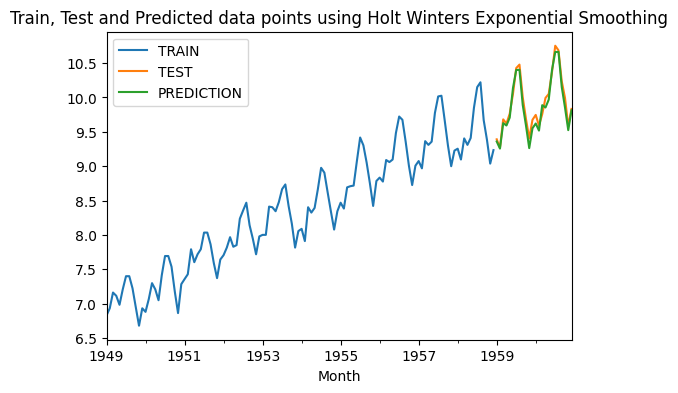

In [26]:
forecast=fit.forecast(24)
forecast_index = pd.date_range(start=test.index[0], periods=24,freq='M') 
test_predictions = pd.Series(forecast.values,index=forecast_index)

train.plot(legend=True,label='TRAIN')
test.plot(legend=True,label='TEST',figsize=(6,4))
test_predictions.plot(legend=True,label='PREDICTION')
plt.title('Train, Test and Predicted data points using Holt Winters Exponential Smoothing')
plt.show()

In [28]:
from pmdarima.arima import ndiffs, nsdiffs

# For regular differencing
ndiffs(df['#Passengers_box_cox'], test='kpss')

1

In [29]:

# For seasonal differencing
nsdiffs(df['#Passengers_box_cox'],m=12)  # m = seasonal period (e.g., 12 for monthly)

1

In [30]:
test

Month
1959-01-01     9.390185
1959-02-01     9.268060
1959-03-01     9.680148
1959-04-01     9.619587
1959-05-01     9.762834
1959-06-01    10.050719
1959-07-01    10.426263
1959-08-01    10.476884
1959-09-01    10.002893
1959-10-01     9.686134
1959-11-01     9.403431
1959-12-01     9.674150
1960-01-01     9.745316
1960-02-01     9.588816
1960-03-01     9.757007
1960-04-01     9.992158
1960-05-01    10.050719
1960-06-01    10.365310
1960-07-01    10.751451
1960-08-01    10.684048
1960-09-01    10.234572
1960-10-01     9.992158
1960-11-01     9.582622
1960-12-01     9.831859
Name: #Passengers_box_cox, dtype: float64

In [31]:
from statsmodels.tsa.ar_model import AutoReg

model = AutoReg(train, lags=12)
fitted_model = model.fit()

# View coefficients
print(fitted_model.params)

# Forecast next 5 steps
forecast = fitted_model.predict(start=len(train), end=len(train)+24)

const                      0.437907
#Passengers_box_cox.L1     0.455094
#Passengers_box_cox.L2    -0.189153
#Passengers_box_cox.L3     0.138123
#Passengers_box_cox.L4    -0.219365
#Passengers_box_cox.L5     0.223133
#Passengers_box_cox.L6    -0.123918
#Passengers_box_cox.L7     0.097709
#Passengers_box_cox.L8    -0.232823
#Passengers_box_cox.L9     0.218342
#Passengers_box_cox.L10   -0.161908
#Passengers_box_cox.L11    0.229738
#Passengers_box_cox.L12    0.534929
dtype: float64


C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


In [96]:
train

Month
1949-01-01     6.827489
1949-02-01     6.932822
1949-03-01     7.161891
1949-04-01     7.114610
1949-05-01     6.983786
                ...    
1958-08-01    10.219682
1958-09-01     9.668139
1958-10-01     9.383538
1958-11-01     9.036736
1958-12-01     9.233166
Name: #Passengers_box_cox, Length: 120, dtype: float64

In [97]:
len(test)

24

In [94]:
forecast

1951-01-01    7.334975
1951-02-01    7.364784
1951-03-01    7.592712
1951-04-01    7.539510
1951-05-01    7.466323
1951-06-01    7.830766
1951-07-01    7.953834
1951-08-01    8.042747
1951-09-01    7.861503
1951-10-01    7.552314
1951-11-01    7.238458
1951-12-01    7.576468
1952-01-01    7.646842
1952-02-01    7.799605
1952-03-01    7.976042
1952-04-01    7.908110
1952-05-01    7.957204
1952-06-01    8.071533
1952-07-01    8.380884
1952-08-01    8.316854
1952-09-01    8.280886
1952-10-01    7.828210
1952-11-01    7.782469
1952-12-01    7.835215
1953-01-01    8.087820
Freq: MS, dtype: float64

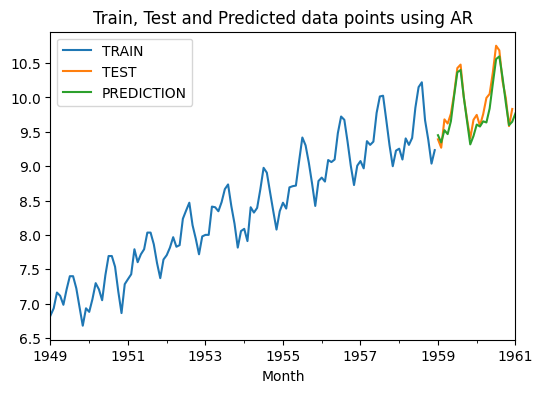

In [32]:
train.plot(legend=True,label='TRAIN')
test.plot(legend=True,label='TEST',figsize=(6,4))
forecast.plot(legend=True,label='PREDICTION')
plt.title('Train, Test and Predicted data points using AR')
plt.show()

In [102]:
train

Month
1949-01-01     6.827489
1949-02-01     6.932822
1949-03-01     7.161891
1949-04-01     7.114610
1949-05-01     6.983786
                ...    
1958-08-01    10.219682
1958-09-01     9.668139
1958-10-01     9.383538
1958-11-01     9.036736
1958-12-01     9.233166
Name: #Passengers_box_cox, Length: 120, dtype: float64

In [104]:
series

1949-01-31   NaN
1949-02-28   NaN
1949-03-31   NaN
1949-04-30   NaN
1949-05-31   NaN
              ..
1958-08-31   NaN
1958-09-30   NaN
1958-10-31   NaN
1958-11-30   NaN
1958-12-31   NaN
Freq: M, Name: #Passengers_box_cox, Length: 120, dtype: float64

In [33]:
from statsmodels.tsa.arima.model import ARIMA

#dates = pd.date_range(start='1949-01-01', periods=len(train), freq='M')
#series = pd.Series(train, index=dates)
model = ARIMA(train, order=(0, 0, 35))
fitted_model = model.fit()

# Summary
print(fitted_model.summary())

C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\stats

                                SARIMAX Results                                
Dep. Variable:     #Passengers_box_cox   No. Observations:                  120
Model:                 ARIMA(0, 0, 35)   Log Likelihood                  86.741
Date:                 Mon, 21 Apr 2025   AIC                            -99.481
Time:                         14:05:09   BIC                              3.656
Sample:                     01-01-1949   HQIC                           -57.597
                          - 12-01-1958                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.3398      0.309     26.955      0.000       7.733       8.946
ma.L1          1.1183      3.170      0.353      0.724      -5.095       7.332
ma.L2          1.1977      3.893      0.308 

In [34]:
forecast = fitted_model.forecast(steps=24)


In [109]:
test

Month
1959-01-01     9.390185
1959-02-01     9.268060
1959-03-01     9.680148
1959-04-01     9.619587
1959-05-01     9.762834
1959-06-01    10.050719
1959-07-01    10.426263
1959-08-01    10.476884
1959-09-01    10.002893
1959-10-01     9.686134
1959-11-01     9.403431
1959-12-01     9.674150
1960-01-01     9.745316
1960-02-01     9.588816
1960-03-01     9.757007
1960-04-01     9.992158
1960-05-01    10.050719
1960-06-01    10.365310
1960-07-01    10.751451
1960-08-01    10.684048
1960-09-01    10.234572
1960-10-01     9.992158
1960-11-01     9.582622
1960-12-01     9.831859
Name: #Passengers_box_cox, dtype: float64

In [107]:
forecast

1959-01-01    9.086566
1959-02-01    8.830246
1959-03-01    8.776490
1959-04-01    8.541930
1959-05-01    8.484844
1959-06-01    8.649725
1959-07-01    8.697342
1959-08-01    8.715019
1959-09-01    8.451581
1959-10-01    8.363419
1959-11-01    8.265844
1959-12-01    8.347040
1960-01-01    8.337716
1960-02-01    8.337716
1960-03-01    8.337716
1960-04-01    8.337716
1960-05-01    8.337716
1960-06-01    8.337716
1960-07-01    8.337716
1960-08-01    8.337716
1960-09-01    8.337716
1960-10-01    8.337716
1960-11-01    8.337716
1960-12-01    8.337716
Freq: MS, Name: predicted_mean, dtype: float64

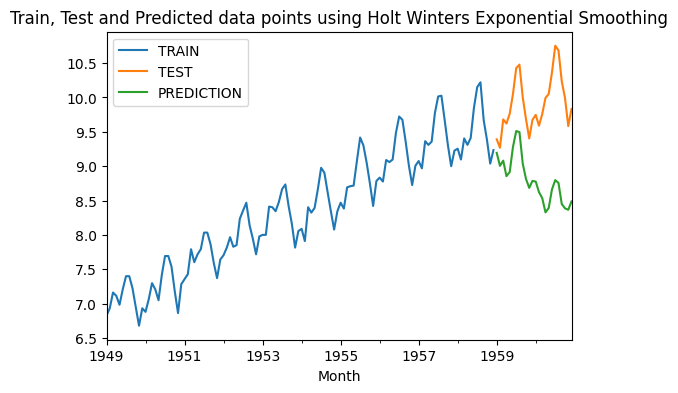

In [35]:
train.plot(legend=True,label='TRAIN')
test.plot(legend=True,label='TEST',figsize=(6,4))
forecast.plot(legend=True,label='PREDICTION')
plt.title('Train, Test and Predicted data points using Holt Winters Exponential Smoothing')
plt.show()

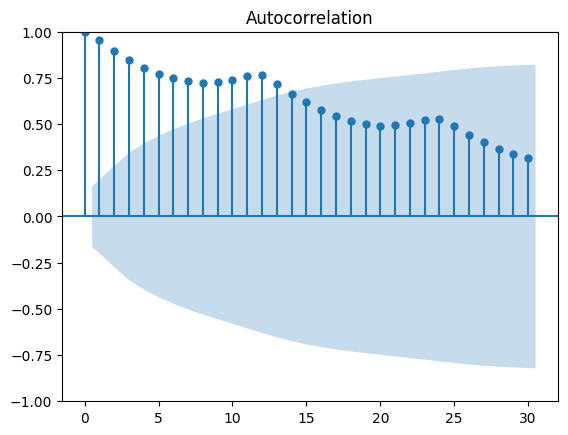

In [36]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
acf=plot_acf(df['#Passengers_box_cox'],lags=30)


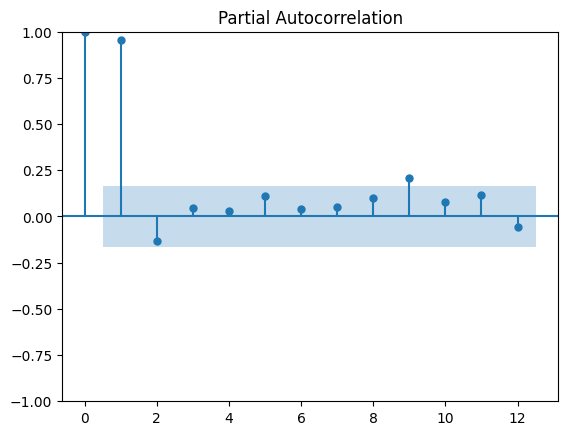

In [37]:
acf=plot_pacf(df['#Passengers_box_cox'],lags=12)

In [38]:
method_kwargs = {'maxiter': 1000} 
model = ARIMA(train, order=(9,1,11))
fitted = model.fit()

# Summary of the model
print(fitted.summary())

# Forecast next 12 periods
forecast = fitted.forecast(steps=24)
print(forecast)

C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                SARIMAX Results                                
Dep. Variable:     #Passengers_box_cox   No. Observations:                  120
Model:                 ARIMA(9, 1, 11)   Log Likelihood                  94.171
Date:                 Mon, 21 Apr 2025   AIC                           -146.341
Time:                         14:05:43   BIC                            -87.980
Sample:                     01-01-1949   HQIC                          -122.643
                          - 12-01-1958                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3486      0.418      0.834      0.405      -0.471       1.168
ar.L2         -0.1079      0.054     -2.015      0.044      -0.213      -0.003
ar.L3          0.0867      0.064      1.364 

C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


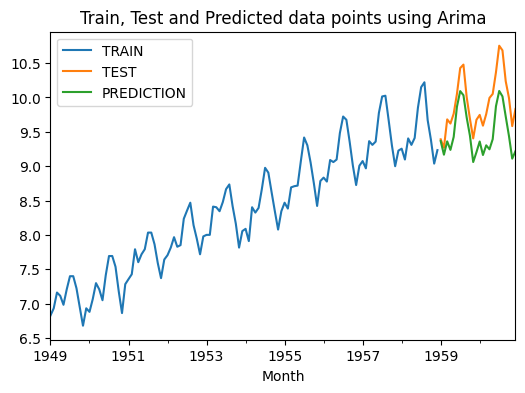

In [39]:
train.plot(legend=True,label='TRAIN')
test.plot(legend=True,label='TEST',figsize=(6,4))
forecast.plot(legend=True,label='PREDICTION')
plt.title('Train, Test and Predicted data points using Arima')
plt.show()

In [40]:
print(fitted.mle_retvals)

{'fopt': -0.7847554823532996, 'gopt': array([-0.04399335, -0.04738471, -0.03033458, -0.02321839, -0.03011768,
       -0.02899994,  0.0689275 , -0.00431395,  0.01146183, -0.04487008,
       -0.03334458,  0.00048102, -0.04525473, -0.01392187,  0.07611661,
       -0.02295053, -0.01166777,  0.04257776,  0.00568653, -0.03313614,
       -0.10831159]), 'fcalls': 1276, 'warnflag': 1, 'converged': False, 'iterations': 50}


In [41]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Assume you have a monthly time series with yearly seasonality
model = SARIMAX(train,
                order=(9,1,11),        # non-seasonal part
                seasonal_order=(1,1,1, 12))  # seasonal part (m=12)
fitted_model = model.fit()



C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\lenovo\AppData

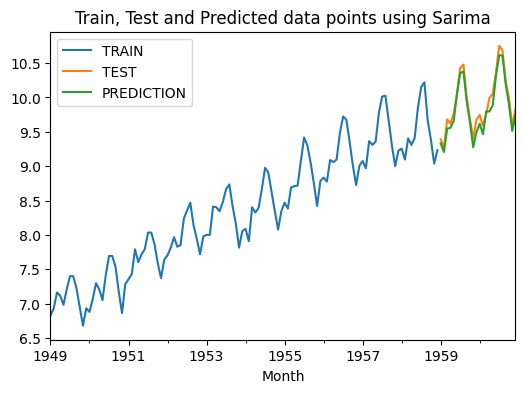

In [42]:
forecast = fitted_model.forecast(steps=24) 
train.plot(legend=True,label='TRAIN')
test.plot(legend=True,label='TEST',figsize=(6,4))
forecast.plot(legend=True,label='PREDICTION')
plt.title('Train, Test and Predicted data points using Sarima')
plt.show()

In [43]:
type(train)
train_df=pd.DataFrame(train)

In [44]:
train_df.reset_index(inplace=True)

In [45]:
train_df.head()

,Month,#Passengers_box_cox
0,1949-01-01,6.827489
1,1949-02-01,6.932822
2,1949-03-01,7.161891
3,1949-04-01,7.114610
4,1949-05-01,6.983786


In [46]:
train_df.rename(columns={'Month':'ds','#Passengers_box_cox':'y'},inplace=True)

In [47]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,   # no weekly in monthly data
    daily_seasonality=False
)
model.fit(train_df)

# Make future dataframe
future = model.make_future_dataframe(periods=24, freq='M')  # forecast 12 months ahead

# Forecast
forecast = model.predict(future)

C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
14:06:09 - cmdstanpy - INFO - Chain [1] start processing
14:06:09 - cmdstanpy - INFO - Chain [1] done processing


In [48]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,6.977999,6.659180,6.884761,6.977999,6.977999,-0.205586,-0.205586,-0.205586,-0.205586,-0.205586,-0.205586,0.0,0.0,0.0,6.772414
1,1949-02-01,6.994774,6.638194,6.852081,6.994774,6.994774,-0.245147,-0.245147,-0.245147,-0.245147,-0.245147,-0.245147,0.0,0.0,0.0,6.749627
2,1949-03-01,7.009925,6.980831,7.198314,7.009925,7.009925,0.075285,0.075285,0.075285,0.075285,0.075285,0.075285,0.0,0.0,0.0,7.085210
3,1949-04-01,7.026699,6.901376,7.124618,7.026699,7.026699,-0.016969,-0.016969,-0.016969,-0.016969,-0.016969,-0.016969,0.0,0.0,0.0,7.009731
4,1949-05-01,7.042933,6.890971,7.106475,7.042933,7.042933,-0.043596,-0.043596,-0.043596,-0.043596,-0.043596,-0.043596,0.0,0.0,0.0,6.999337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,1960-07-31,9.885114,10.151195,10.465404,9.782745,9.983164,0.425960,0.425960,0.425960,0.425960,0.425960,0.425960,0.0,0.0,0.0,10.311074
140,1960-08-31,9.898786,9.902226,10.211401,9.787805,10.004303,0.161780,0.161780,0.161780,0.161780,0.161780,0.161780,0.0,0.0,0.0,10.060566
141,1960-09-30,9.912016,9.565165,9.889135,9.790969,10.024307,-0.185102,-0.185102,-0.185102,-0.185102,-0.185102,-0.185102,0.0,0.0,0.0,9.726914
142,1960-10-31,9.925688,9.219917,9.565944,9.798112,10.044065,-0.531609,-0.531609,-0.531609,-0.531609,-0.531609,-0.531609,0.0,0.0,0.0,9.394079


In [49]:
forecast.set_index(keys='ds')['yhat']

ds
1949-01-01     6.772414
1949-02-01     6.749627
1949-03-01     7.085210
1949-04-01     7.009731
1949-05-01     6.999337
                ...    
1960-07-31    10.311074
1960-08-31    10.060566
1960-09-30     9.726914
1960-10-31     9.394079
1960-11-30     9.698833
Name: yhat, Length: 144, dtype: float64

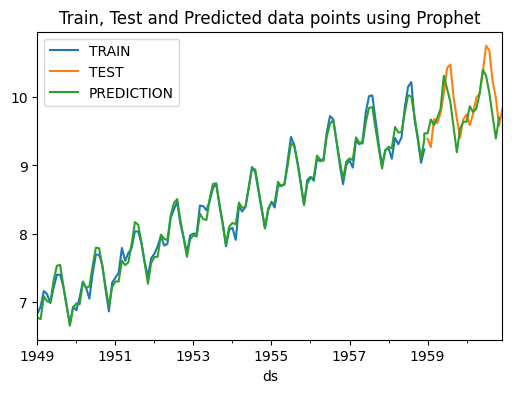

In [50]:
train.plot(legend=True,label='TRAIN')
test.plot(legend=True,label='TEST',figsize=(6,4))
forecast.set_index(keys='ds')['yhat'].plot(legend=True,label='PREDICTION')
plt.title('Train, Test and Predicted data points using Prophet')
plt.show()